In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import seaborn as sns
import random


In [3]:
stn = 1
chn = 25

In [5]:
fn = f"traces_station{stn}_channel{chn}_pol{chn%2}.dat"
data = pd.read_csv("traces_127417834/"+fn, delimiter="\t")

In [6]:
modified = pd.concat([data.columns.to_frame().T, data]).reset_index(drop=True).iloc[:,0].str.split(expand=True).astype(float)
modified

,0,1
0,0.0,-5.969695e-10
1,5.0,-3.357519e-10
2,10.0,1.921449e-09
3,15.0,8.477217e-10
4,20.0,-4.329742e-09
...,...,...
65531,327655.0,1.541678e-09
65532,327660.0,1.189878e-09
65533,327665.0,-4.887822e-09
65534,327670.0,2.009925e-10


In [7]:
time = modified.values[:,0]
trace = modified.values[:,1]

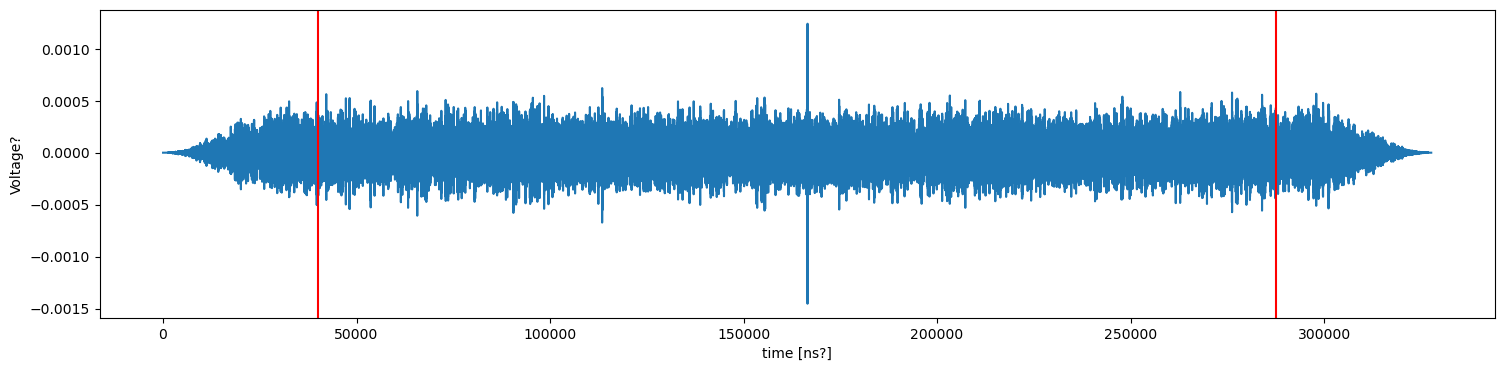

In [8]:
plt.figure(figsize = (18,4))
plt.xlabel("time [ns?]")
plt.ylabel("Voltage?")
plt.plot(time, trace)
plt.axvline(x=40000, c="r")
plt.axvline(x=5*len(time)-40000, c="r")
plt.show()

I need to compare 1D plots 
So I need covariance matrices of the ones I want to compare

RemoveSig2 returns --> full trace, covariance matrix, plot of matrix, zoomed in, 1D plot
it can change <-- Name of the file, output folder, trim, duration, sigwindow

1. Make a reduced RemoveSig2.py that returns covariance matrix and plot of matrix, zoomed in and 1D plot (a lot to store) and write another pipeline that compares 1D
2. 1 but only returns matrix
3. make a pipeline that takes multiple files and compare them (input: Name of the file, output folder, trim, duration, sigwindow, number of files to compare.
Output: Big plot with all the cov matrices, big plot with all 1D, and overlaped plot)

# Random Comparison

In [1]:
def remove_signal(trace, sig_window):
    sig = np.argmax(trace)
    return np.delete(trace, np.arange(sig-sig_window,sig+sig_window+1))

def get_reals(trace, dur):
    to_consider = trace[:-(len(trace)%dur)]
    return np.split(to_consider, len(to_consider)/dur)

def make_cov(trace, duration, sig_window):
    new_trace = remove_signal(trace, sig_window)
    reals = np.array(get_reals(new_trace, duration))
    N = len(reals)
    print(f"Number of realizations: {N}")

    if N==0:
        return np.zeros((duration, duration)), N

    return np.cov(reals.T), N

 

In [22]:
85*random.random()

2.185470671207242

In [87]:
def get_random_channel(size):
    #87, 87, 85, 87, 87, 85
    stns = []
    chns = []
    for i in range(size):
        stn = int(6*random.random())
        stns.append(stn)
        if stn in (2,5):
            chns.append(int(86*random.random()))
        else:
            chns.append(int(88*random.random()))

    return stns, chns

In [88]:
stns, chns = get_random_channel(10)

In [89]:
stns

[1, 1, 5, 0, 3, 1, 5, 0, 3, 4]

In [90]:
chns

[31, 28, 31, 50, 0, 56, 35, 1, 32, 43]